In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk

In [11]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Fayaz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [13]:
df=pd.read_csv("D:\Sentiment-Analysis\IMDB Dataset.csv.zip")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
print(df.shape)
print(df.info())
print(df['sentiment'].value_counts())

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [18]:
stop_words=set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z]','',text)
    words=text.split()
    words=[word for word in words if word not in stop_words]
    return " ".join(words)

In [25]:
df['clean_text']=df['review'].apply(clean_text)

In [27]:
df['sentiment']=df['sentiment'].map({'positive':1, 
                                    'negative':0
                                   })

In [28]:
tfidf=TfidfVectorizer()
X=tfidf.fit_transform(df['clean_text'])
y=df['sentiment']

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
model=LogisticRegression()

In [31]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
y_pred=model.predict(X_test)

In [33]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.5


In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.66      4961
           1       1.00      0.01      0.02      5039

    accuracy                           0.50     10000
   macro avg       0.75      0.50      0.34     10000
weighted avg       0.75      0.50      0.34     10000



In [35]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[4961    0]
 [5000   39]]


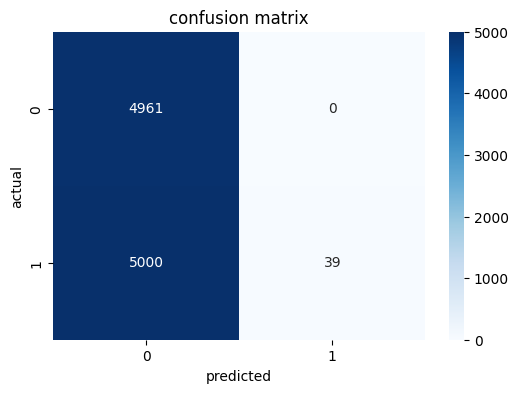

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.savefig("confusion_matrix.png")
plt.show()

In [45]:
review=["the movie was boring"]
review_clean=[clean_text(text) for text in review]
review_vector=tfidf.transform(review_clean)
prediction=model.predict(review_vector)
print(prediction)

[0]


In [44]:
import pickle
pickle.dump(model,open("sentiment_model.pkl","wb"))
pickle.dump(tfidf,open("tfidf_vectorizer.pkl","wb"))